# Depolarizing Channel $\Lambda_p$ & Proposition 1
## No Dataset | Random Density Matrices | Circuit NISQ Demo (Synthetic Features)
### To Confirm: $D_{\mathrm{tr}}(\Lambda_p(\rho),\Lambda_p(\sigma)) = (1-p)\,D_{\mathrm{tr}}(\rho,\sigma)$

## Setup


In [1]:
import pennylane as qp
from pennylane import numpy as np
import torch

import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import time

In [2]:
from scripts.constants import DEFAULT_NOISE_RATE
from scripts.circuit import build_forward_circuit, create_quantum_device, initialize_random_weights
from scripts.quantum_metrics import depolarizing_channel, trace_distance
from scripts.utils import get_torch_device
from scripts.logging import write_history_log

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


In [4]:
NOTEBOOK_NAME = "15.depolarizing-channel"
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = get_torch_device()
print(f"torch device: {device}")

torch device: cuda


## Proposition 1: Noise Contraction

### Claim:

For the global $n$-qubit depolarizing channel
$$
\Lambda_p(\rho) = (1-p)\rho + p\,\frac{I}{2^n}
$$
and any density matrices $\rho,\sigma$,
$$
D_{\mathrm{tr}}\big(\Lambda_p(\rho),\,\Lambda_p(\sigma)\big)
= (1-p)\,D_{\mathrm{tr}}(\rho,\sigma)
$$
is true.

In other words, depolarizing noise **rescales** Hilbert-space geometry by $(1-p)$; it **does not distort** relative angles between pairs.

### Note:

- This is an **exact** identity.
- Residuals should be machine precision ($\sim 10^{-10}$ or smaller).

### To Test:

- $p=0$ (identity), $p=1$ (collapse to maximally mixed state $I/d$, distance $0$), and intermediate $p$.
- **No dataset is required** for this check as random states are the correct testbed.

## $\Lambda_p$ Implementation

In [5]:
def random_density_matrix(dim, device, dtype=torch.complex128):
    """
    Sample a random density matrix: Haar-random pure state via QR, then mix with I/d.
    
    Defaults to complex128 so Proposition 1 residual stays near machine precision.
    """
    z = torch.randn(dim, dim, device=device, dtype=dtype)   # random matrix
    q, _ = torch.linalg.qr(z)   # orthonomal columns
    psi = q[:, 0]   # first column as unit vector
    rho = torch.outer(psi, psi.conj())
    mix = float(torch.rand(1, dtype=torch.float64).item()) * 0.5
    eye = torch.eye(dim, device=device, dtype=dtype) / dim
    rho = (1.0 - mix) * rho + mix * eye
    return 0.5 * (rho + rho.mH)


def prop1_residual(rho, sigma, p):
    """
    Compute Proposition 1 residual: absolute gap between noisy and (1-p)-scaled clean trace distance.
    """
    d_clean = trace_distance(rho, sigma)
    d_noisy = trace_distance(depolarizing_channel(rho, p), depolarizing_channel(sigma, p))
    expected = (1.0 - p) * d_clean
    return float(torch.abs(d_noisy - expected)), float(d_clean), float(d_noisy), float(expected)

## Numerical Confirmation of Proposition 1

For each $n\in\{1,2,3\}$ qubits and $p\in\{0, 0.25, 0.5, 0.75, 1\}$, test *Proposition 1* on 64 random pairs $(ρ,σ)$.

In [6]:
n_pairs = 64
p_grid = [0.0, 0.25, 0.5, 0.75, 1.0]
qubit_grid = [1, 2, 3]

rows = []
t0 = time.perf_counter()
for n_qubits in qubit_grid:
    dim = 2 ** n_qubits
    for p in p_grid:
        residuals = []
        for _ in range(n_pairs):
            rho = random_density_matrix(dim, device)
            sigma = random_density_matrix(dim, device)
            resid, d_clean, d_noisy, expected = prop1_residual(rho, sigma, p)
            residuals.append(resid)
        residuals = np.array(residuals)
        rows.append({
            "n_qubits": n_qubits,
            "p": p,
            "n_pairs": n_pairs,
            "resid_max": float(residuals.max()),
            "resid_mean": float(residuals.mean()),
            "resid_median": float(np.median(residuals)),
        })

prop1_df = pd.DataFrame(rows)
elapsed = time.perf_counter() - t0
print(f"prop-1 sweep done in {elapsed:.2f}s")
prop1_df

prop-1 sweep done in 1.88s


,n_qubits,p,n_pairs,resid_max,resid_mean,resid_median
0,1,0.00,64,0.000000e+00,0.000000e+00,0.000000e+00
1,1,0.25,64,2.220446e-16,5.290907e-17,5.551115e-17
2,1,0.50,64,2.220446e-16,2.238877e-17,0.000000e+00
3,1,0.75,64,8.326673e-17,1.837723e-17,2.081668e-17
4,1,1.00,64,0.000000e+00,0.000000e+00,0.000000e+00
5,2,0.00,64,0.000000e+00,0.000000e+00,0.000000e+00
6,2,0.25,64,4.440892e-16,1.240327e-16,1.110223e-16
7,2,0.50,64,2.775558e-16,5.898060e-17,5.551115e-17
8,2,0.75,64,1.665335e-16,3.079134e-17,2.775558e-17
9,2,1.00,64,0.000000e+00,0.000000e+00,0.000000e+00


In [7]:
# assert Proposition 1 residuals are near machine eps across the whole sweep
TOL = 1e-10
worst = float(prop1_df["resid_max"].max())
assert worst < TOL, f"Proposition 1 residual too large: {worst}"
print(f"Proposition 1 PASSED | worst residual = {worst:.3e} < {TOL:g}")

Proposition 1 PASSED | worst residual = 6.661e-16 < 1e-10


In [8]:
# edge cases: p=0 (identity) and p=1 (collapse to I/d)
rho = random_density_matrix(4, device)
sigma = random_density_matrix(4, device)
r0, *_ = prop1_residual(rho, sigma, 0.0)
r1, *_ = prop1_residual(rho, sigma, 1.0)
assert r0 < TOL and r1 < TOL
print(f"p=0 residual={r0:.3e} | p=1 residual={r1:.3e}")

p=0 residual=0.000e+00 | p=1 residual=0.000e+00


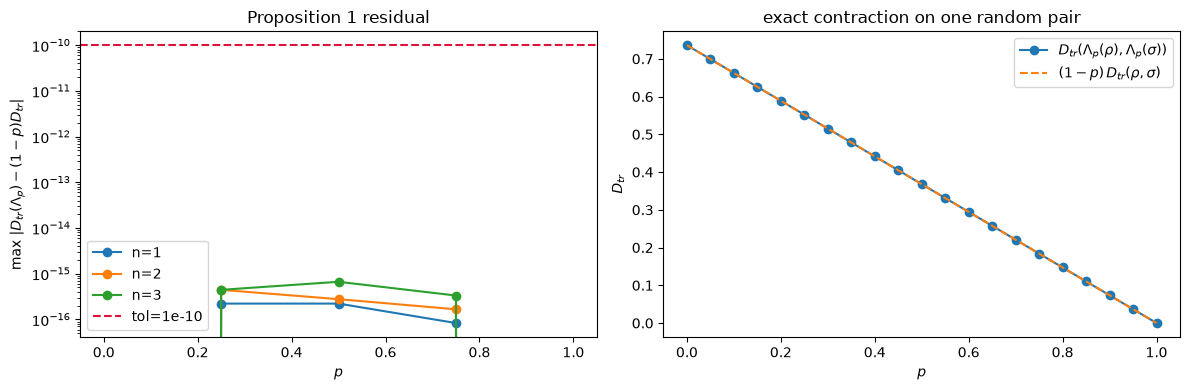

In [9]:
# plot residual vs p
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for n_qubits, g in prop1_df.groupby("n_qubits"):
    axes[0].plot(g["p"], g["resid_max"], marker="o", label=f"n={n_qubits}")
axes[0].axhline(TOL, color="crimson", linestyle="--", label=f"tol={TOL:g}")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$p$")
axes[0].set_ylabel(r"max $|D_{tr}(\Lambda_p)- (1-p)D_{tr}|$")
axes[0].set_title("Proposition 1 residual")
axes[0].legend()

# show the contraction itself on one fixed pair
n_qubits = 2
dim = 2 ** n_qubits
rho = random_density_matrix(dim, device)
sigma = random_density_matrix(dim, device)
p_fine = np.linspace(0.0, 1.0, 21)
d_clean = float(trace_distance(rho, sigma))
d_noisy = [float(trace_distance(depolarizing_channel(rho, float(p)), depolarizing_channel(sigma, float(p)))) for p in p_fine]
axes[1].plot(p_fine, d_noisy, "o-", label=r"$D_{tr}(\Lambda_p(\rho),\Lambda_p(\sigma))$")
axes[1].plot(p_fine, (1.0 - p_fine) * d_clean, "--", label=r"$(1-p)\,D_{tr}(\rho,\sigma)$")
axes[1].set_xlabel(r"$p$")
axes[1].set_ylabel(r"$D_{tr}$")
axes[1].set_title("exact contraction on one random pair")
axes[1].legend()

plt.tight_layout()
plt.show()

## $p$ as NISQ Noise (Circuit)

In the QS-Net forward path, $p$ enters as per-wire `DepolarizingChannel` after each variational layer:

$$
x \xrightarrow{\phi} \ket{\psi(x)}
\xrightarrow{U(\theta)} \ket{\Phi(x)}
\xrightarrow{\Lambda_p^{\otimes}} \rho(x)
$$

In [10]:
num_qubits = 4
num_layers = 2
noise_rate = DEFAULT_NOISE_RATE # default NISQ knob

dev = create_quantum_device(num_qubits)
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)
theta = initialize_random_weights(num_layers, num_qubits, device)

# synthetic features in [0, pi]
X_syn = torch.rand(8, num_qubits, device=device) * np.pi
with torch.no_grad():
    z, rho_batch = forward_circuit(X_syn, theta)

print(f"noise rate (p) = {noise_rate}")
print(f"weights (theta) shape = {tuple(theta.shape)}")
print(f"density-matrix (rho) batch shape = {tuple(rho_batch.shape)}")
print(f"mean |Pauli-Z measurement| = {torch.stack([zi.abs().mean() for zi in z]).mean().item():.4f}")

noise rate (p) = 0.01
weights (theta) shape = (2, 4, 3)
density-matrix (rho) batch shape = (8, 16, 16)
mean |Pauli-Z measurement| = 0.3604


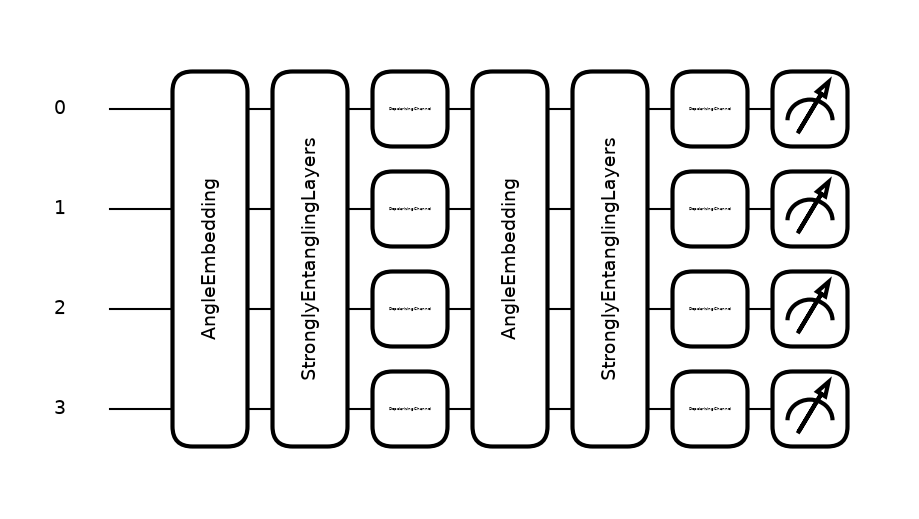

In [11]:
# draw one sample through the noisy circuit
fig, ax = qp.draw_mpl(forward_circuit)(X_syn[:1], theta)
plt.show()

## $p$ as a Regulariser Knob

Because Proposition 1 contracts *every* pair by $(1-p)$, raising $p$:

- shrinks inter-prototype / inter-sample trace distances
- softens Hilbert-space geometry (harder to over-separate classes)
- shrinks the certified radius denominator factor $(1-p)$ in Algo 3

So the same scalar is both a **hardware-noise model** and a **geometry regulariser**.

In [12]:
# run a noiseless circuit
dev_clean = create_quantum_device(num_qubits)
forward_clean = build_forward_circuit(dev_clean, num_qubits, num_layers, noise_rate=0.0)# noiseless

with torch.no_grad():
    _, rho_clean = forward_clean(X_syn, theta)

rho_list = [rho_clean[i] for i in range(rho_clean.shape[0])]

In [13]:
def mean_pairwise_td(states):
    """
    Mean trace distance over all unique pairs of states.
    """
    vals = []
    for i in range(len(states)):
        for j in range(i + 1, len(states)):
            vals.append(float(trace_distance(states[i], states[j])))
    return float(np.mean(vals)) if vals else 0.0

In [14]:
# raise p and check that average state-to-state distance shrinks by the factor (1-p)
d0 = mean_pairwise_td(rho_list)
p_reg_grid = np.linspace(0.0, 1.0, 11)
d_p = []
for p in p_reg_grid:
    noisy = [depolarizing_channel(r, float(p)) for r in rho_list]
    d_p.append(mean_pairwise_td(noisy))

reg_df = pd.DataFrame({
    "p": p_reg_grid,
    "mean_pairwise_Dtr": d_p,
    "theory_(1-p)*D0": (1.0 - p_reg_grid) * d0,
})
reg_df

,p,mean_pairwise_Dtr,theory_(1-p)*D0
0,0.0,0.920578,0.920578
1,0.1,0.828520,0.828520
2,0.2,0.736462,0.736462
3,0.3,0.644405,0.644405
4,0.4,0.552347,0.552347
5,0.5,0.460289,0.460289
6,0.6,0.368231,0.368231
7,0.7,0.276173,0.276173
8,0.8,0.184116,0.184116
9,0.9,0.092058,0.092058


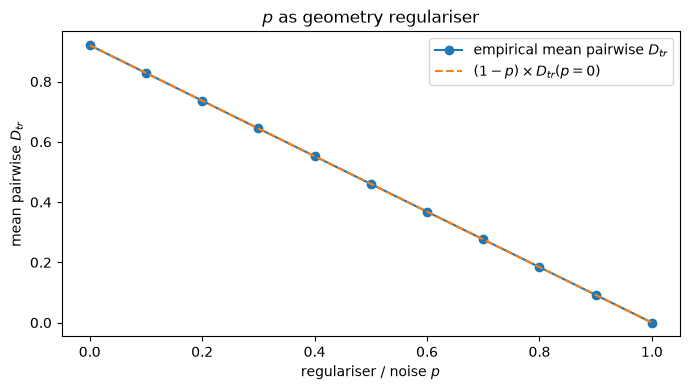

regulariser-curve residual max = 2.220e-16


In [15]:
# plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(reg_df["p"], reg_df["mean_pairwise_Dtr"], "o-", label="empirical mean pairwise $D_{tr}$")
ax.plot(reg_df["p"], reg_df["theory_(1-p)*D0"], "--", label=r"$(1-p)\times D_{tr}(p=0)$")
ax.set_xlabel(r"regulariser / noise $p$")
ax.set_ylabel(r"mean pairwise $D_{tr}$")
ax.set_title(r"$p$ as geometry regulariser")
ax.legend()
plt.tight_layout()
plt.show()

reg_resid = np.max(np.abs(reg_df["mean_pairwise_Dtr"] - reg_df["theory_(1-p)*D0"]))
print(f"regulariser-curve residual max = {reg_resid:.3e}")

## Logging


In [16]:
history = {
    "prop1_resid_max": prop1_df["resid_max"].tolist(),
    "prop1_resid_mean": prop1_df["resid_mean"].tolist(),
    "p_grid": p_grid,
    "reg_mean_pairwise_Dtr": reg_df["mean_pairwise_Dtr"].tolist(),
}

log_path = write_history_log(
    history,
    NOTEBOOK_NAME,
    extra={
        "seed": SEED,
        "n_pairs": n_pairs,
        "qubit_grid": qubit_grid,
        "p_grid": p_grid,
        "prop1_tol": TOL,
        "prop1_worst_residual": worst,
        "prop1_passed": bool(worst < TOL),
        "circuit_num_qubits": num_qubits,
        "circuit_num_layers": num_layers,
        "circuit_noise_rate": noise_rate,
        "reg_p_grid": p_reg_grid.tolist(),
        "reg_D0": d0,
        "reg_resid_max": float(reg_resid),
        "dataset": None,
    },
)
print(f"wrote {log_path}")

# also dump the residual table
csv_path = Path("logs") / f"{NOTEBOOK_NAME}-prop1.csv"
csv_path.parent.mkdir(parents=True, exist_ok=True)
prop1_df.to_csv(csv_path, index=False)
print(f"wrote {csv_path}")

wrote logs/15.depolarizing-channel.log
wrote logs/15.depolarizing-channel-prop1.csv
